#EMBEDDING WITH SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

In [1]:
#!pip install ipywidgets --q


In [2]:
# !pip install sentence-transformers xgboost scikit-learn pandas optuna tensorboard joblib --q

In [3]:
import os, joblib, pandas as pd, numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from datetime import datetime

e:\KLTN\Data_mining\env1\Lib\site-packages\transformers\utils\hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [4]:
df = pd.read_csv("datas/combined.csv").dropna(subset=["combined_text","story_point"])
texts = df["combined_text"].tolist()
y = df["story_point"].values

In [5]:
len(texts), len(y)

(93056, 93056)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93056 entries, 0 to 93055
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            93056 non-null  object 
 1   story_point    93056 non-null  float64
 2   title          93056 non-null  object 
 3   description    90223 non-null  object 
 4   combined_text  93056 non-null  object 
dtypes: float64(1), object(4)
memory usage: 3.5+ MB


In [7]:
df["story_point"]

0         2.0
1         5.0
2        20.0
3         5.0
4        13.0
         ... 
93051     1.0
93052     2.0
93053     3.0
93054     2.0
93055     2.0
Name: story_point, Length: 93056, dtype: float64

In [8]:
df.duplicated().sum()

np.int64(1586)

In [9]:
# Xóa các dữ liệu issue trùng lặp
df = df.drop_duplicates().copy()
# Update texts and y to reflect the cleaned DataFrame
texts_cleaned = df["combined_text"].tolist()
y_cleaned = df["story_point"].values

print(f"Texts: {len(texts)}  --> {len(texts_cleaned)}")
print(f"Y: {len(y)}  --> {len(y_cleaned)}")

# Sử dụng texts_cleaned và y_cleaned cho các bước tiếp theo

Texts: 93056  --> 91470
Y: 93056  --> 91470


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Kiểm tra giá trị null -- Description bị null không sao, 
#       Phần train sẽ chỉ lấy mỗi combined_text (title + desc) 
#       hoặc có thể bỏ các dòng dữ liệu đó luôn
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
key                 0
story_point         0
title               0
description      2778
combined_text       0
dtype: int64


In [12]:
print(df.describe(include='all'))

           key  story_point         title description combined_text
count    91470  91470.00000         91470       88692         91470
unique      28          NaN         38784       42975         87857
top     TISTUD          NaN  lint failure      #NAME?  Provisioning
freq     27999          NaN            16          61             4
mean       NaN      4.63751           NaN         NaN           NaN
std        NaN      7.77140           NaN         NaN           NaN
min        NaN      0.00000           NaN         NaN           NaN
25%        NaN      1.00000           NaN         NaN           NaN
50%        NaN      3.00000           NaN         NaN           NaN
75%        NaN      5.00000           NaN         NaN           NaN
max        NaN    100.00000           NaN         NaN           NaN


In [13]:
!pip install -U matplotlib seaborn -q


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


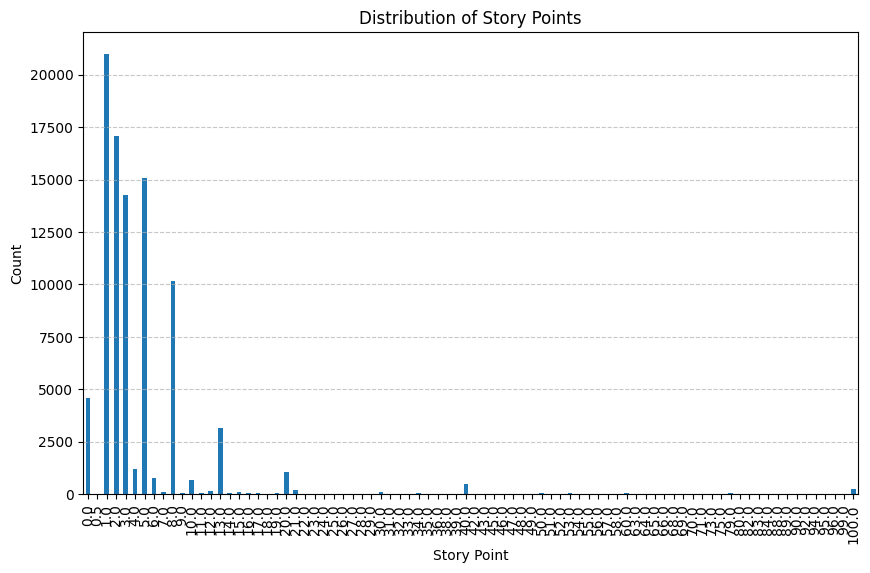

In [14]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df['story_point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

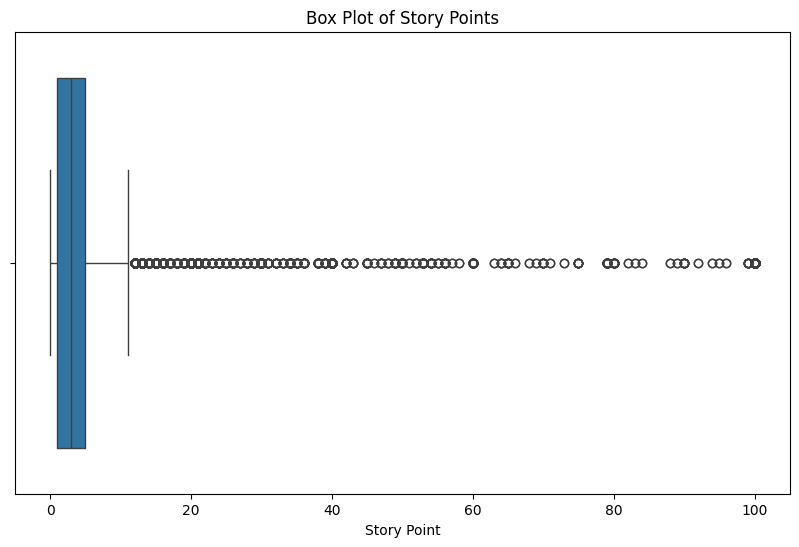

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['story_point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

In [16]:
#Xử lý giá trị ngoại lai
Q1 = df['story_point'].quantile(0.25)
Q3 = df['story_point'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered = df[(df['story_point'] >= lower_bound) & (df['story_point'] <= upper_bound)].copy()

# Update texts and y to reflect the filtered DataFrame
texts_filtered = df_filtered["combined_text"].tolist()
y_filtered = df_filtered["story_point"].values

print(f"Data shape: {df.shape} --> {df_filtered.shape}")

# LƯU Ý LÀ SỬ DỤNG: df_filtered, texts_filtered, and y_filtered cho các bước sau

Data shape: (91470, 5) --> (85044, 5)


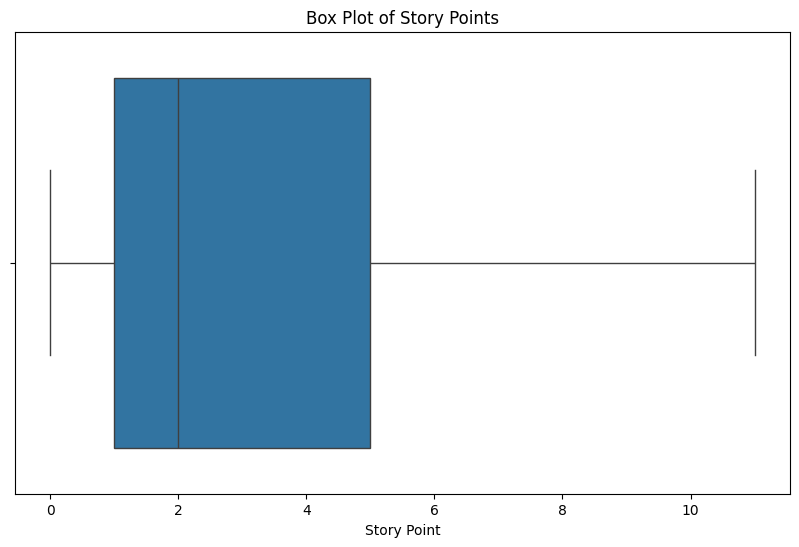

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered['story_point'])
plt.title('Box Plot of Story Points')
plt.xlabel('Story Point')
plt.show()

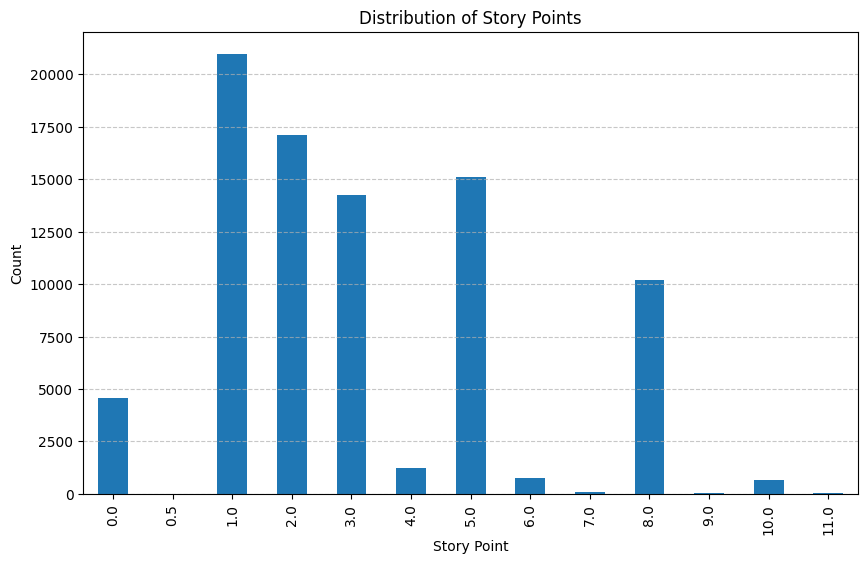

In [18]:
# Phân bố story point
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_filtered['story_point'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Story Points')
plt.xlabel('Story Point')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
df_filtered.shape

(85044, 5)

In [20]:
df_filtered.head()

,key,story_point,title,description,combined_text
0,JSW,2.0,"Add text to the Agile Gadget ""Invalid Project""...","When the error is ""Invalid Project"" add detail...","Add text to the Agile Gadget ""Invalid Project""..."
1,JSW,5.0,Generic webwork aliases may clash with other p...,Some web work actions have commands that have ...,Generic webwork aliases may clash with other p...
3,JSW,5.0,Version can be set in the create issue screen ...,Costumer has a project in which some users don...,Version can be set in the create issue screen ...
6,JSW,3.0,GreenHopper appends Project IDs to URL when ad...,Per ticket here: https://support.atlassian.com...,GreenHopper appends Project IDs to URL when ad...
7,JSW,2.0,Investigate: Log work operation of a task in t...,*Steps to reproduce:* 1. Click on Agile Tab 2....,Investigate: Log work operation of a task in t...


In [21]:
texts_filtered[1]

'Generic webwork aliases may clash with other plugins. Some web work actions have commands that have very generic aliases, such as "Update", "Move" and "Synch" etc. These aliases have a good chance to clash with the action name or aliases used by other plugins. These aliases should be given a name specific to the plugin, such as "UpdateGreenHopperDropBoard"... Alternatively, the bang syntax can be used in place of command aliases, such as "DropBoardAction!update". In this case, there is no need to define aliases for commands. (However, still need to define alias as an empty String; otherwise, a NPE will be thrown when parsing the xml.)'

In [22]:
# !pip install -q -U sentence-transformers tqdm --quiet

In [23]:
# Chuẩn hóa Mã dự án (Key)
from sklearn.preprocessing import LabelEncoder

# Encode key
le = LabelEncoder()
df_filtered["key_encoder"] = le.fit_transform(df_filtered["key"].astype(str))



In [24]:
df_filtered["key_encoder"].unique() # Các mã key của dự án được mã hóa thành các số

array([14, 16, 15, 18, 22, 23, 26,  2,  4, 25,  0,  1,  3,  5,  6,  7,  8,
        9, 10, 11, 12, 13, 17, 19, 20, 21, 24, 27])

In [25]:
# Thêm các đặc trưng về độ dài văn bản
df_filtered["word_count"] = df_filtered["combined_text"].apply(lambda x: len(x.split()))
df_filtered["char_count"] = df_filtered["combined_text"].apply(lambda x: len(x))
# Chuẩn hóa các đặc trưng độ dài
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_filtered[["word_norm", "char_norm"]] = scaler.fit_transform(df_filtered[["word_count", "char_count"]])

In [26]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85044 entries, 0 to 93055
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            85044 non-null  object 
 1   story_point    85044 non-null  float64
 2   title          85044 non-null  object 
 3   description    82627 non-null  object 
 4   combined_text  85044 non-null  object 
 5   key_encoder    85044 non-null  int64  
 6   word_count     85044 non-null  int64  
 7   char_count     85044 non-null  int64  
 8   word_norm      85044 non-null  float64
 9   char_norm      85044 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 7.1+ MB


In [27]:
df_filtered.head()

,key,story_point,title,description,combined_text,key_encoder,word_count,char_count,word_norm,char_norm
0,JSW,2.0,"Add text to the Agile Gadget ""Invalid Project""...","When the error is ""Invalid Project"" add detail...","Add text to the Agile Gadget ""Invalid Project""...",14,37,364,0.000879,0.000258
1,JSW,5.0,Generic webwork aliases may clash with other p...,Some web work actions have commands that have ...,Generic webwork aliases may clash with other p...,14,105,642,0.002539,0.000458
3,JSW,5.0,Version can be set in the create issue screen ...,Costumer has a project in which some users don...,Version can be set in the create issue screen ...,14,110,645,0.002661,0.000460
6,JSW,3.0,GreenHopper appends Project IDs to URL when ad...,Per ticket here: https://support.atlassian.com...,GreenHopper appends Project IDs to URL when ad...,14,103,753,0.002490,0.000537
7,JSW,2.0,Investigate: Log work operation of a task in t...,*Steps to reproduce:* 1. Click on Agile Tab 2....,Investigate: Log work operation of a task in t...,14,83,481,0.002002,0.000342


In [28]:
from sentence_transformers import SentenceTransformer
import numpy as np
import json, os
from tqdm.notebook import tqdm
import time

# chọn model

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embed_model = SentenceTransformer(MODEL_NAME, device="cuda")

def get_embedding(text):
    # if text in emb_cache:
    #     return emb_cache[text]

    emb = embed_model.encode(text, normalize_embeddings=True).tolist()
    # emb_cache[text] = emb
    return emb


# Embed toàn bộ data
embeddings_list = []
texts = df_filtered["combined_text"].tolist()

start_time = time.perf_counter()

for text in tqdm(texts, desc="Embedding texts..."):
    emb = get_embedding(text)
    embeddings_list.append(emb)
    
end_time = time.perf_counter()
# Lưu cache
# with open(CACHE_FILE, "w", encoding="utf-8") as f:
#     json.dump(emb_cache, f, ensure_ascii=False)

X_emb = np.array(embeddings_list)
print("✅ Done! Shape:", X_emb.shape)
print(f"Time taken for embedding: {end_time - start_time:.2f} seconds")


Embedding texts...:   0%|          | 0/85044 [00:00<?, ?it/s]

✅ Done! Shape: (85044, 384)
Time taken for embedding: 995.79 seconds


In [47]:
np.save("embedX/[MiniL12]X_embed.npy", X_emb)
print("Saved embeddings to [MiniL12]X_embed.npy.npy")

Saved embeddings to [MiniL12]X_embed.npy.npy


In [48]:
test_emb = np.load("embedX/[MiniL12]X_embed.npy")
test_emb.shape

(85044, 384)

In [29]:
embeddings_list[1]

[-0.09008987993001938,
 -0.03997006267309189,
 -0.03963552787899971,
 -0.0037968610413372517,
 0.042705465108156204,
 0.04675595462322235,
 0.052242595702409744,
 -0.08203645050525665,
 -0.0003878187562804669,
 0.03504643216729164,
 0.003837790573015809,
 0.01492453832179308,
 0.01852918416261673,
 -0.03158808499574661,
 0.12508206069469452,
 0.0025807577185332775,
 0.00905860960483551,
 0.016662972047924995,
 0.011513451114296913,
 0.01945894956588745,
 -0.07810306549072266,
 0.0003875072579830885,
 0.016025368124246597,
 0.05873744189739227,
 -0.08407285809516907,
 -0.011518611572682858,
 -0.02388625405728817,
 -0.00227326899766922,
 -0.02784018963575363,
 -0.06674568355083466,
 0.06746423989534378,
 0.04589489474892616,
 -0.016505401581525803,
 -0.0074296873062849045,
 -0.0654427632689476,
 -0.00580961350351572,
 -0.06968177109956741,
 -0.01402035541832447,
 -0.08378778398036957,
 -0.06984296441078186,
 -0.0025203607510775328,
 -0.031305696815252304,
 -0.048963990062475204,
 -0.0661

In [30]:
# Kết hợp embedding với các đặc trưng độ dài
extra = df_filtered[["word_norm", "char_norm", "key_encoder"]].values
X = np.hstack([X_emb, extra])

In [31]:
print("X_emb shape:", X_emb.shape)
print("extra shape:", extra.shape)
print("Final X shape:", X.shape)

X_emb shape: (85044, 384)
extra shape: (85044, 3)
Final X shape: (85044, 387)


In [32]:
X[1]

array([-9.00898799e-02, -3.99700627e-02, -3.96355279e-02, -3.79686104e-03,
        4.27054651e-02,  4.67559546e-02,  5.22425957e-02, -8.20364505e-02,
       -3.87818756e-04,  3.50464322e-02,  3.83779057e-03,  1.49245383e-02,
        1.85291842e-02, -3.15880850e-02,  1.25082061e-01,  2.58075772e-03,
        9.05860960e-03,  1.66629720e-02,  1.15134511e-02,  1.94589496e-02,
       -7.81030655e-02,  3.87507258e-04,  1.60253681e-02,  5.87374419e-02,
       -8.40728581e-02, -1.15186116e-02, -2.38862541e-02, -2.27326900e-03,
       -2.78401896e-02, -6.67456836e-02,  6.74642399e-02,  4.58948947e-02,
       -1.65054016e-02, -7.42968731e-03, -6.54427633e-02, -5.80961350e-03,
       -6.96817711e-02, -1.40203554e-02, -8.37877840e-02, -6.98429644e-02,
       -2.52036075e-03, -3.13056968e-02, -4.89639901e-02, -6.61616400e-02,
       -4.07092050e-02, -1.02629168e-02,  2.30692141e-02, -8.73914827e-03,
       -5.85359372e-02, -6.14651106e-03, -3.10674943e-02, -7.69801736e-02,
        6.38662232e-03,  

In [33]:
y = df_filtered["story_point"].values
y.shape

(85044,)

In [34]:
import numpy as np

X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

print(" Converted to numpy arrays")
print("X shape:", X.shape)
print("y shape:", y.shape)

 Converted to numpy arrays
X shape: (85044, 387)
y shape: (85044,)


In [35]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)



Shape of X_train: (68035, 387)
Shape of X_test: (17009, 387)
Shape of y_train: (68035,)
Shape of y_test: (17009,)


In [36]:
X_train[1]

array([ 1.58941792e-03,  5.87490294e-03,  3.98241132e-02, -4.14217077e-02,
        4.60716523e-02, -5.33310045e-03, -2.12505609e-02,  5.65870153e-03,
        6.07175846e-03, -2.89185671e-03, -4.24994975e-02,  2.66575254e-02,
       -4.56793718e-02, -3.53735499e-02, -2.33971234e-02, -2.48209629e-02,
       -6.84233941e-03, -5.09159593e-03, -2.39205881e-04, -1.41763547e-02,
       -6.04666285e-02, -4.41418849e-02,  4.02032472e-02,  4.23731777e-04,
       -5.21956719e-02,  1.01173483e-01, -4.98531982e-02,  6.08527362e-02,
        1.18069343e-01, -4.09998782e-02,  3.52376066e-02,  9.54657570e-02,
       -6.03926964e-02, -2.69552059e-02,  1.68653224e-02,  5.05250022e-02,
        1.94484834e-02, -6.59888163e-02, -1.30006492e-01, -6.98113739e-02,
        2.37283334e-02, -7.92896599e-02,  9.25998092e-02,  2.84451842e-02,
       -8.15614536e-02, -1.42102903e-02, -2.93409303e-02,  4.22251225e-03,
       -6.99610114e-02, -4.92911190e-02, -1.23735778e-01, -7.48111978e-02,
        6.26101568e-02, -

In [37]:
# !pip install lazypredict --quiet
# !pip install ipywidgets --upgrade
# !pip install --upgrade ipywidgets jupyter
# !pip install --upgrade xgboost --quiet

TRAIN XGBRegressor

In [38]:
# pip install --upgrade xgboost --q


In [39]:
import xgboost
print(xgboost.__version__)


3.1.1


In [40]:
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import time

xgb_model = XGBRegressor(
    n_estimators=10000,           # cho phép chạy max (model tự dừng trước)
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    min_child_weight=2,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=50,   # dừng nếu 50 rounds không cải thiện
)

start_time = time.perf_counter()
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],

    verbose=500                  # log sau mỗi 500 bước
)
end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:.2f} seconds")

preds = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")


[0]	validation_0-rmse:2.39538
[500]	validation_0-rmse:1.95375
[1000]	validation_0-rmse:1.87960
[1500]	validation_0-rmse:1.82498
[2000]	validation_0-rmse:1.78308
[2500]	validation_0-rmse:1.75051
[3000]	validation_0-rmse:1.72468
[3500]	validation_0-rmse:1.70468
[4000]	validation_0-rmse:1.68823
[4500]	validation_0-rmse:1.67422
[5000]	validation_0-rmse:1.66297
[5500]	validation_0-rmse:1.65331
[6000]	validation_0-rmse:1.64526
[6500]	validation_0-rmse:1.63866
[7000]	validation_0-rmse:1.63297
[7500]	validation_0-rmse:1.62835
[8000]	validation_0-rmse:1.62428
[8500]	validation_0-rmse:1.62091
[9000]	validation_0-rmse:1.61811
[9500]	validation_0-rmse:1.61565
[9999]	validation_0-rmse:1.61352
Training time: 706.77 seconds
RMSE: 1.6135
R2: 0.5517


In [41]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error

# baseline
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("Baseline mean R2:", r2_score(y_test, pred_dummy))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, pred_dummy)))

# distribution labels
print("y stats:", np.min(y), np.max(y), np.mean(y), np.std(y))
print(pd.Series(y).value_counts().sort_index())


Baseline mean R2: -7.99801300275238e-05
Baseline RMSE: 2.409816598006873
y stats: 0.0 11.0 3.206610695639904 2.427225287957611
0.0      4588
0.5         2
1.0     20977
2.0     17100
3.0     14251
4.0      1219
5.0     15088
6.0       763
7.0        98
8.0     10182
9.0        64
10.0      672
11.0       40
Name: count, dtype: int64


In [42]:
import pandas as pd
import numpy as np

# ---- So sánh dự đoán với giá trị thật ----
compare_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": preds,
})

compare_df["absolute_error"] = np.abs(compare_df["y_true"] - compare_df["y_pred"])
compare_df["squared_error"] = (compare_df["y_true"] - compare_df["y_pred"]) ** 2

print(compare_df.head(5))     # in 5 dòng đầu

print("\n====== METRICS ======")
print(f"MAE: {compare_df['absolute_error'].mean():.4f}")
print(f"MSE: {compare_df['squared_error'].mean():.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


   y_true    y_pred  absolute_error  squared_error
0     2.0  3.802223        1.802223       3.248008
1     2.0  1.759622        0.240378       0.057781
2     5.0  5.068759        0.068759       0.004728
3     3.0  3.889978        0.889978       0.792062
4     2.0  6.080447        4.080447      16.650049

====== METRICS ======
MAE: 1.1615
MSE: 2.6034
RMSE: 1.6135
R²: 0.5517


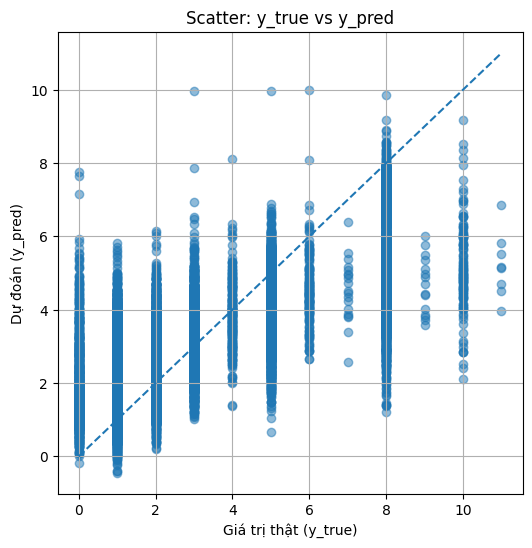

In [43]:
plt.figure(figsize=(6,6))
plt.scatter(compare_df["y_true"], compare_df["y_pred"], alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], linestyle='--')  # đường y=x
plt.xlabel("Giá trị thật (y_true)")
plt.ylabel("Dự đoán (y_pred)")
plt.title("Scatter: y_true vs y_pred")
plt.grid(True)
plt.show()


In [44]:
def predict_story_point(title: str, desc: str, project_key: str):
    # Combine text
    text = (title or "") + " " + (desc or "")

    # ---- EMBEDDING ----
    emb = embed_model.encode(
        text,
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    # ---- EXTRA FEATURES ----
    word_count = len(text.split())
    char_count = len(text)

    # scale word_norm, char_norm
    extra = pd.DataFrame([[word_count, char_count]], columns=["word_count", "char_count"])
    extra_scaled = scaler.transform(extra)

    # PROJECT KEY (enc)
    key_encoded = le.transform([project_key])[0]

    # FINAL FEATURE VECTOR
    X_input = np.hstack([
        emb.reshape(1, -1),          # shape (1, 384)
        extra_scaled,                # shape (1, 2)
        np.array([[key_encoded]])    # shape (1, 1)
    ])

    # ---- PREDICT ----
    pred = xgb_model.predict(X_input)[0]

    return round(float(pred), 2)


In [45]:
# Danh sách test tiếng Việt
# Load embedding model
embed_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device="cuda")
test_cases = [
    ("Lỗi đăng nhập", "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.", "JSW"),
    ("Thêm tooltip UI", "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.", "TIDOC"),
    ("Tối ưu backend", "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.", "MDL"),
    ("Sửa lỗi crash khi upload file", "Ứng dụng bị crash khi upload file trên trình duyệt Safari.", "MDL"),
    ("Thêm phân quyền mới", "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.", "TIDOC"),
    ("Cải thiện tốc độ tìm kiếm", "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.", "JSW"),
    ("Fix lỗi hiển thị UI", "Icon menu bị lệch vị trí trên màn hình iPhone 12.", "JSW"),
    ("Thêm login bằng Facebook", "Người dùng có thể đăng nhập bằng tài khoản Facebook.", "JSW"),
    ("Phát triển dashboard thống kê", "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.", "TIDOC"),
    ("Sửa lỗi email không gửi", "Hệ thống không gửi email xác thực đối với domain Outlook.", "JSW")
]

print(" Kết quả dự đoán Story Point:")
for title, desc, key in test_cases:
    pred_sp = predict_story_point(title, desc, key)
    print(f" Title: {title} - Predicted Story Point: {pred_sp}\n")


 Kết quả dự đoán Story Point:
 Title: Lỗi đăng nhập - Predicted Story Point: 3.17

 Title: Thêm tooltip UI - Predicted Story Point: 3.24

 Title: Tối ưu backend - Predicted Story Point: 4.67

 Title: Sửa lỗi crash khi upload file - Predicted Story Point: 3.36

 Title: Thêm phân quyền mới - Predicted Story Point: 1.36

 Title: Cải thiện tốc độ tìm kiếm - Predicted Story Point: 5.62

 Title: Fix lỗi hiển thị UI - Predicted Story Point: 3.02

 Title: Thêm login bằng Facebook - Predicted Story Point: 3.55

 Title: Phát triển dashboard thống kê - Predicted Story Point: 2.86

 Title: Sửa lỗi email không gửi - Predicted Story Point: 3.26



In [46]:
# Test cases song ngữ (theo cặp)
test_pairs = [
    (
        ("Lỗi đăng nhập", "Người dùng không thể đăng nhập bằng Google trên ứng dụng di động.", "JSW"),
        ("Login error", "Users cannot log in with Google on the mobile app.", "JSW")
    ),
    (
        ("Thêm tooltip UI", "Thêm tooltip cho nút tạo task để người dùng hiểu rõ chức năng.", "TIDOC"),
        ("Add UI tooltip", "Add tooltip for the create task button to help users understand its function.", "TIDOC")
    ),
    (
        ("Tối ưu backend", "Refactor toàn bộ API, cải thiện tốc độ phản hồi cho hệ thống.", "MDL"),
        ("Optimize backend", "Refactor all APIs to improve system response speed.", "MDL")
    ),
    (
        ("Sửa lỗi crash khi upload file", "Ứng dụng bị crash khi upload file trên trình duyệt Safari.", "MDL"),
        ("Fix crash on file upload", "The app crashes when uploading files on Safari browser.", "MDL")
    ),
    (
        ("Thêm phân quyền mới", "Thêm quyền 'Supervisor' để xem báo cáo nhưng không được chỉnh sửa task.", "TIDOC"),
        ("Add new permission", "Add 'Supervisor' role to view reports but not edit tasks.", "TIDOC")
    ),
    (
        ("Cải thiện tốc độ tìm kiếm", "Tối ưu query và thêm caching để kết quả tìm kiếm hiển thị nhanh hơn.", "JSW"),
        ("Improve search speed", "Optimize queries and add caching to speed up search results.", "JSW")
    ),
    (
        ("Fix lỗi hiển thị UI", "Icon menu bị lệch vị trí trên màn hình iPhone 12.", "JSW"),
        ("Fix UI display issue", "Menu icon is misaligned on iPhone 12 screen.", "JSW")
    ),
    (
        ("Thêm login bằng Facebook", "Người dùng có thể đăng nhập bằng tài khoản Facebook.", "JSW"),
        ("Add login with Facebook", "Users can log in using their Facebook accounts.", "JSW")
    ),
    (
        ("Phát triển dashboard thống kê", "Xây dựng dashboard hiển thị KPI dự án theo thời gian thực.", "TIDOC"),
        ("Develop statistics dashboard", "Build a dashboard to display project KPIs in real-time.", "TIDOC")
    ),
    (
        ("Sửa lỗi email không gửi", "Hệ thống không gửi email xác thực đối với domain Outlook.", "JSW"),
        ("Fix email sending issue", "The system fails to send verification emails for Outlook domain.", "JSW")
    )
]

print("====== KẾT QUẢ DỰ ĐOÁN STORY POINT (Song ngữ) ======\n")

for (title_vn, desc_vn, key_vn), (title_en, desc_en, key_en) in test_pairs:
    pred_sp_vn = predict_story_point(title_vn, desc_vn, key_vn)
    pred_sp_en = predict_story_point(title_en, desc_en, key_en)
    
    print(f"\nTitle: {title_vn}")
    print(f"Vie: {pred_sp_vn} | Eng: {pred_sp_en} | Chênh lệch: {abs(pred_sp_vn - pred_sp_en)}")


====== KẾT QUẢ DỰ ĐOÁN STORY POINT (Song ngữ) ======


Title: Lỗi đăng nhập
Vie: 3.17 | Eng: 2.85 | Chênh lệch: 0.31999999999999984

Title: Thêm tooltip UI
Vie: 3.24 | Eng: 2.78 | Chênh lệch: 0.4600000000000004

Title: Tối ưu backend
Vie: 4.67 | Eng: 5.23 | Chênh lệch: 0.5600000000000005

Title: Sửa lỗi crash khi upload file
Vie: 3.36 | Eng: 3.12 | Chênh lệch: 0.23999999999999977

Title: Thêm phân quyền mới
Vie: 1.36 | Eng: 1.65 | Chênh lệch: 0.2899999999999998

Title: Cải thiện tốc độ tìm kiếm
Vie: 5.62 | Eng: 5.37 | Chênh lệch: 0.25

Title: Fix lỗi hiển thị UI
Vie: 3.02 | Eng: 2.72 | Chênh lệch: 0.2999999999999998

Title: Thêm login bằng Facebook
Vie: 3.55 | Eng: 3.54 | Chênh lệch: 0.009999999999999787

Title: Phát triển dashboard thống kê
Vie: 2.86 | Eng: 3.47 | Chênh lệch: 0.6100000000000003

Title: Sửa lỗi email không gửi
Vie: 3.26 | Eng: 3.3 | Chênh lệch: 0.040000000000000036


In [50]:
import joblib

# Lưu XGBRegressor
joblib.dump(xgb_model, "models/minil12/[MiniL12]_xgb.pkl")
print("Đã lưu: models/minil12/[MiniL12]_xgb.pkl")

# Lưu Scaler
joblib.dump(scaler, "models/minil12/[MiniL12]_scaler.pkl")


Đã lưu: models/minil12/[MiniL12]_xgb.pkl


['models/minil12/[MiniL12]_scaler.pkl']

In [51]:

loaded_xgb = joblib.load("models/minil12/[MiniL12]_xgb.pkl")
loaded_scaler = joblib.load("models/minil12/[MiniL12]_scaler.pkl")

print(type(loaded_xgb))
print(type(loaded_scaler))


<class 'xgboost.sklearn.XGBRegressor'>
<class 'sklearn.preprocessing._data.MinMaxScaler'>
